# 26 — Date enrichment recovery

How many individuals are dated, and **where the date comes from**.

Several complementary techniques add temporal information for individuals who initially had no birth date, active period, or death date recorded in Wikidata. We count each method **recursively**: once an individual is dated by one source, they are excluded from the count of subsequent sources, so the additions sum to the total.

Order of recovery (matching the paper paragraph):

1. **Original** — at least one date in Wikidata (`birthdate` P569 / `deathdate` P570 / `floruit_date` P1317).
2. **From descriptions** — any year token mined from the Wikidata/Wikipedia description (`birthdate_in_description`, `deathdate_in_description`, `floruit_year_in_description`, `dates_in_description`).
3. **From works** — earliest/latest dated work bound to the author (`works_period`, after the death-date cap built in notebook step 20).
4. **From the Cross-Verified DB** — year-precise lookup (`birthdate_from_CV`, `deathdate_from_CV`).
5. **From country-of-citizenship spans** — the inception/dissolution years of the countries the individual is a citizen of (`country_of_citizenship.inception` and `.dissolved`), joined by **Q-id** through `individuals_keys.country_of_citizenship_ids`. A coarse but wide-coverage fallback: e.g. someone tagged "Khedivate of Egypt; Egypt" inherits the union of those countries' lifespans.

We then report the overall precision split. Year/decade precision flows from the floruit-period builder and from inception/publication precision codes; the country-span fallback contributes to the *century-or-beyond* bucket only (the span is intrinsically wide).

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = "../data/humans_clean.duckdb"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

COLOR_ORIGINAL = "#2171b5"
COLOR_DESC     = "#6a9e3a"
COLOR_WORKS    = "#b5542a"
COLOR_CV       = "#7f7f7f"
COLOR_NONE     = "#d9d9d9"
PALETTE = [COLOR_ORIGINAL, COLOR_DESC, COLOR_WORKS, COLOR_CV, COLOR_NONE]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## 1. Load

In [ ]:
import duckdb
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

# We go through pandas because polars' read_database fails on SQLite's
# dynamic typing for several mixed-type columns (e.g. CV/life-expectancy
# columns mixing year integers and ISO strings). pandas reads everything
# as object, then we convert to polars cleanly.
conn = duckdb.connect(DB_PATH, read_only=True)

ind_pd = conn.execute("""
    SELECT wikidata_id,
           birthdate, deathdate, floruit_date,
           birthdate_in_description, deathdate_in_description,
           floruit_year_in_description, dates_in_description,
           works_period,
           birthdate_from_CV, deathdate_from_CV
    FROM individuals
    """).df()

fp_pd = conn.execute("""
    SELECT wikidata_id, precision_class
    FROM individuals_floruit_period
    """).df()

# Per-individual best precision across their dated works.
# Wikidata precision codes: 11=day, 10=month, 9=year, 8=decade, 7=century,
# 6=millennium, ≤5 = ten-thousand-year+. eff_prec per work = inception_precision
# if inception_date is set, else publication_precision. Per individual we take
# the MAX (best) across their works — if any work is year-precise, we treat
# the individual's works-period as year-precise.
works_prec_pd = conn.execute("""
    SELECT individual_id,
           MAX(CASE
                 WHEN inception_date IS NOT NULL THEN inception_precision
                 WHEN publication_date IS NOT NULL THEN publication_precision
               END) AS best_work_precision
    FROM works
    WHERE inception_date IS NOT NULL OR publication_date IS NOT NULL
    GROUP BY individual_id
    """).df()

# Per-individual country-of-citizenship date span. We match by Q-id (not by
# name) using `individuals_keys.country_of_citizenship_ids` (semicolon-
# separated list of country Q-ids). For each individual we aggregate
# min(inception year) and max(dissolved year) across their countries that
# have at least one of the two dates set.
coc_pd = conn.execute("""
    WITH coc AS (
      SELECT k.wikidata_id,
             TRIM(value) AS country_qid
      FROM individuals_keys k, json_each('["' || REPLACE(k.country_of_citizenship_ids, ';', '","') || '"]')
      WHERE k.country_of_citizenship_ids IS NOT NULL
    )
    SELECT coc.wikidata_id,
           MIN(CASE WHEN c.inception IS NOT NULL THEN
                  CAST(CASE WHEN substr(c.inception,1,1)='-'
                            THEN substr(c.inception,1,5)
                            ELSE substr(c.inception,1,4) END AS INTEGER) END) AS coc_inception,
           MAX(CASE WHEN c.dissolved IS NOT NULL THEN
                  CAST(CASE WHEN substr(c.dissolved,1,1)='-'
                            THEN substr(c.dissolved,1,5)
                            ELSE substr(c.dissolved,1,4) END AS INTEGER) END) AS coc_dissolved
    FROM coc
    JOIN country_of_citizenship c ON c.wikidata_id = coc.country_qid
    WHERE c.inception IS NOT NULL OR c.dissolved IS NOT NULL
    GROUP BY coc.wikidata_id
    """).df()
conn.close()

ind = pl.from_pandas(ind_pd)
fp  = pl.from_pandas(fp_pd)
works_prec = pl.from_pandas(works_prec_pd).rename({"individual_id": "wikidata_id"})
coc = pl.from_pandas(coc_pd)
del ind_pd, fp_pd, works_prec_pd, coc_pd

print(f"individuals: {ind.height:,}")
print(f"individuals_floruit_period: {fp.height:,}")
print(f"individuals with at least one dated work: {works_prec.height:,}")
print(f"individuals with country-of-citizenship dates: {coc.height:,}")
ind.head()

## 2. Source flags

One boolean per recovery source. The flags are *not* mutually exclusive — an individual can be covered by several sources at once. The recursive accounting in section 3 picks one per individual following the priority order.

In [3]:
ind = ind.with_columns([
    (pl.col("birthdate").is_not_null()
     | pl.col("deathdate").is_not_null()
     | pl.col("floruit_date").is_not_null()).alias("has_original"),
    (pl.col("birthdate_in_description").is_not_null()
     | pl.col("deathdate_in_description").is_not_null()
     | pl.col("floruit_year_in_description").is_not_null()
     | pl.col("dates_in_description").is_not_null()).alias("has_description"),
    pl.col("works_period").is_not_null().alias("has_works"),
    (pl.col("birthdate_from_CV").is_not_null()
     | pl.col("deathdate_from_CV").is_not_null()).alias("has_cv"),
])

# Country-of-citizenship flag: present in the coc lookup table.
ind = ind.join(
    coc.select(["wikidata_id"]).with_columns(pl.lit(True).alias("has_coc")),
    on="wikidata_id", how="left",
).with_columns(pl.col("has_coc").fill_null(False))

ind = ind.with_columns(
    (pl.col("has_original") | pl.col("has_description")
     | pl.col("has_works")  | pl.col("has_cv")
     | pl.col("has_coc")).alias("has_any")
)

flag_summary = pl.DataFrame({
    "source": ["original", "description", "works", "cv", "country_of_citizenship", "any"],
    "n": [
        int(ind["has_original"].sum()),
        int(ind["has_description"].sum()),
        int(ind["has_works"].sum()),
        int(ind["has_cv"].sum()),
        int(ind["has_coc"].sum()),
        int(ind["has_any"].sum()),
    ],
})
flag_summary

source,n
str,i64
"""original""",7813121
"""description""",2212747
"""works""",2760563
"""cv""",2132294
"""country_of_citizenship""",5565202
"""any""",11010897


## 3. Recursive recovery

Priority (each individual counted once, on the first matching source):
`original → description → works → cv → country_of_citizenship`.
Individuals with no source remain undated.

In [4]:
recovery = (
    ind.with_columns(
        pl.when(pl.col("has_original")).then(pl.lit("1_original"))
          .when(pl.col("has_description")).then(pl.lit("2_description"))
          .when(pl.col("has_works")).then(pl.lit("3_works"))
          .when(pl.col("has_cv")).then(pl.lit("4_cv"))
          .when(pl.col("has_coc")).then(pl.lit("5_country_of_citizenship"))
          .otherwise(pl.lit("6_none"))
          .alias("recovery_source")
    )
)

rec_counts = (
    recovery.group_by("recovery_source")
            .agg(pl.len().alias("n"))
            .with_columns((pl.col("n") / ind.height * 100).round(2).alias("share_%"))
            .sort("recovery_source")
)
total = ind.height
rec_counts = rec_counts.with_columns(pl.lit(total).alias("total"))
print(f"Total individuals: {total:,}")
rec_counts

Total individuals: 13,003,420


recovery_source,n,share_%,total
str,u32,f64,i32
"""1_original""",7813121,60.09,13003420
"""2_description""",173209,1.33,13003420
"""3_works""",2166963,16.66,13003420
"""4_cv""",3105,0.02,13003420
"""5_country_of_citizenship""",854499,6.57,13003420
"""6_none""",1992523,15.32,13003420


In [5]:
# Sanity: shares should sum to 100% (small drift from rounding to 2 decimals is fine)
assert abs(rec_counts["share_%"].sum() - 100.0) < 0.05, rec_counts["share_%"].sum()
# Sanity: all individuals accounted for
assert int(rec_counts["n"].sum()) == ind.height

### Figure: recovery breakdown

A horizontal bar showing how each source contributes.

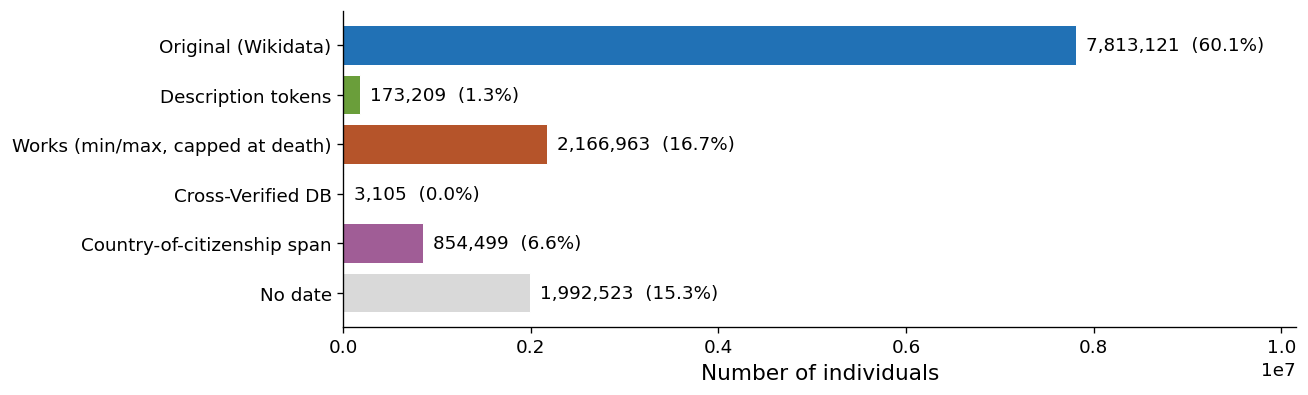

In [6]:
label_map = {
    "1_original":               "Original (Wikidata)",
    "2_description":            "Description tokens",
    "3_works":                  "Works (min/max, capped at death)",
    "4_cv":                     "Cross-Verified DB",
    "5_country_of_citizenship": "Country-of-citizenship span",
    "6_none":                   "No date",
}
color_map = {
    "1_original":               COLOR_ORIGINAL,
    "2_description":            COLOR_DESC,
    "3_works":                  COLOR_WORKS,
    "4_cv":                     COLOR_CV,
    "5_country_of_citizenship": "#a05d96",
    "6_none":                   COLOR_NONE,
}

plot_df = rec_counts.sort("recovery_source").to_pandas()
plot_df["label"] = plot_df["recovery_source"].map(label_map)
plot_df["color"] = plot_df["recovery_source"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.barh(plot_df["label"], plot_df["n"],
        color=plot_df["color"], edgecolor="white", linewidth=0.6)
for y, (n, p) in enumerate(zip(plot_df["n"], plot_df["share_%"])):
    ax.annotate(f"{n:,}  ({p:.1f}%)", xy=(n, y),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=11)
ax.set_xlabel("Number of individuals")
ax.invert_yaxis()
ax.margins(x=0.30)
plt.tight_layout()
plt.show()

## 4. Originally-dated baseline

This is the "before enrichment" count: individuals with at least one date directly from Wikidata (P569/P570/P1317).

In [7]:
n_total = ind.height
n_original = int(ind["has_original"].sum())
print(f"Originally dated (Wikidata only): {n_original:,} of {n_total:,}  ({n_original/n_total*100:.1f}%)")

Originally dated (Wikidata only): 7,813,121 of 13,003,420  (60.1%)


## 5. Precision distribution

Every individual dated by one of the five sources gets a precision class:

1. **Floruit-period precision** — `individuals_floruit_period.precision_class` ('year' / 'decade' / 'century'). Set when the date came from Wikidata or a description token. We exclude its `'polity'` entries to keep the picture confined to the five explicit sources.
2. **Works-period precision** — for individuals whose only date signal is `works_period`, we derive precision from the underlying inception/publication precision codes (`inception_precision` / `publication_precision`). Mapping: code ≥ 9 → `'year'`, code = 8 → `'decade'`, code ≤ 7 → `'century'`.
3. **Country-of-citizenship precision** — always `'century'` (the span is intrinsically wide — a country's lifetime is decades to centuries).

Bucket reported in the paper:

- **Year or decade** = `'year'` ∪ `'decade'`.
- **Century or beyond** = `'century'`.

In [8]:
# 5a. Floruit-period precision (canonical)
prec = (
    fp.group_by("precision_class")
      .agg(pl.len().alias("n"))
      .sort("precision_class", nulls_last=True)
)
prec

precision_class,n
str,u32
"""century""",125583
"""decade""",113072
"""polity""",970191
"""year""",7444711
null,4349340


In [9]:
# 5b. Works-period precision: map best_work_precision (Wikidata code) → class
def code_to_class(code):
    if code is None:
        return None
    if code >= 9:
        return "year"
    if code == 8:
        return "decade"
    return "century"  # codes 0..7 — century or coarser

works_prec = works_prec.with_columns(
    pl.col("best_work_precision")
      .map_elements(code_to_class, return_dtype=pl.Utf8)
      .alias("works_precision_class")
)
works_prec.head()

wikidata_id,best_work_precision,works_precision_class
str,i64,str
"""Q1000002""",9,"""year"""
"""Q1000005""",11,"""year"""
"""Q1000006""",11,"""year"""
"""Q100005""",9,"""year"""
"""Q100013293""",9,"""year"""


In [10]:
# 5c. Unified per-individual precision following the recursive priority:
# (a) floruit-period precision_class (excluding 'polity' fallback)
# (b) works-derived precision (from inception/publication codes)
# (c) country-of-citizenship → 'century'
# Individuals with none of these have no precision_unified.
fp_clean = fp.with_columns(
    pl.when(pl.col("precision_class") == "polity")
      .then(pl.lit(None, dtype=pl.Utf8))
      .otherwise(pl.col("precision_class"))
      .alias("precision_class")
)

combined = (
    ind.select(["wikidata_id", "has_works", "has_coc"])
       .join(fp_clean.select(["wikidata_id", "precision_class"]), on="wikidata_id", how="left")
       .join(works_prec.select(["wikidata_id", "works_precision_class"]), on="wikidata_id", how="left")
       .with_columns(
           pl.when(pl.col("precision_class").is_not_null())
             .then(pl.col("precision_class"))
             .when(pl.col("works_precision_class").is_not_null())
             .then(pl.col("works_precision_class"))
             .when(pl.col("has_coc"))
             .then(pl.lit("century"))
             .otherwise(pl.lit(None, dtype=pl.Utf8))
             .alias("precision_unified")
       )
)

unified_dist = (
    combined.group_by("precision_unified")
            .agg(pl.len().alias("n"))
            .sort("precision_unified", nulls_last=True)
)
unified_dist

precision_unified,n
str,u32
"""century""",1204567
"""decade""",113337
"""year""",9615249
null,2070267


In [11]:
def n_for(df, cls):
    return int(df.filter(pl.col("precision_unified") == cls)["n"].sum() or 0)

n_year_decade  = n_for(unified_dist, "year") + n_for(unified_dist, "decade")
n_century_plus = n_for(unified_dist, "century")
n_no_class     = int(unified_dist.filter(pl.col("precision_unified").is_null())["n"].sum() or 0)

print(f"Year-precise to the decade: {n_year_decade:,}")
print(f"Century-precise or coarser: {n_century_plus:,}")
print(f"No precision (no date from the five sources): {n_no_class:,}")
print()
print(f"Total dated (with a precision): {n_year_decade + n_century_plus:,}")

Year-precise to the decade: 9,728,586
Century-precise or coarser: 1,204,567
No precision (no date from the five sources): 2,070,267

Total dated (with a precision): 10,933,153


### Pre-1500 cohort: how coarsely is it dated?

For each dated individual we attach a representative year. Source priority follows `precision_unified`:

- **Floruit-period dated** → `floruit_period_start` from `individuals_floruit_period`.
- **Works-only dated** → midpoint of `works_period` ("YYYY-YYYY").
- **Country-of-citizenship-only dated** → midpoint of their countries' span (`coc_inception`/`coc_dissolved`, defaulting to 2026 if a country is still extant).

We then filter to `rep_year < 1500` and report what fraction of the pre-1500 cohort is century-precise (i.e. carries no better than a century-wide bracket).

In [ ]:
# 1) floruit-period start year for ALL precision classes (year/decade/century).
conn = duckdb.connect(DB_PATH, read_only=True)
fp_full = pl.from_pandas(conn.execute("""
    SELECT wikidata_id, floruit_period_start, precision_class
    FROM individuals_floruit_period
    WHERE precision_class IN ('year','decade','century')
    """).df())
conn.close()

# 2) works-period midpoint, BCE-safe.
def _works_midpoint(s):
    if s is None: return None
    leading_minus = s.startswith('-')
    body = s[1:] if leading_minus else s
    bits = body.split('-')
    if len(bits) == 1:
        try: return int(s)
        except: return None
    a = -int(bits[0]) if leading_minus else int(bits[0])
    rest = '-'.join(bits[1:])
    b = -int(rest[1:]) if rest.startswith('-') else int(rest)
    return (a + b) // 2

works_mid = (
    ind.select(["wikidata_id", "works_period"])
       .filter(pl.col("works_period").is_not_null())
       .with_columns(
           pl.col("works_period").map_elements(_works_midpoint, return_dtype=pl.Int64).alias("works_year")
       )
       .select(["wikidata_id", "works_year"])
)

# 3) country-of-citizenship midpoint, defaulting dissolved → 2026 if extant.
coc_mid = coc.with_columns(
    pl.when(pl.col("coc_dissolved").is_null())
      .then(pl.lit(2026, dtype=pl.Int64))
      .otherwise(pl.col("coc_dissolved")).alias("coc_diss_filled"),
).with_columns(
    ((pl.col("coc_inception").fill_null(pl.col("coc_diss_filled"))
      + pl.col("coc_diss_filled")) / 2).cast(pl.Int64).alias("coc_year")
).select(["wikidata_id", "coc_year"])

# Representative year for every individual with precision_unified set,
# following the same precedence as precision_unified.
dated = (
    combined
      .filter(pl.col("precision_unified").is_not_null())
      .join(fp_full.select(["wikidata_id", "floruit_period_start"]), on="wikidata_id", how="left")
      .join(works_mid, on="wikidata_id", how="left")
      .join(coc_mid, on="wikidata_id", how="left")
      .with_columns(
          pl.when(pl.col("precision_class").is_not_null())
            .then(pl.col("floruit_period_start"))
            .when(pl.col("works_precision_class").is_not_null())
            .then(pl.col("works_year"))
            .when(pl.col("has_coc"))
            .then(pl.col("coc_year"))
            .otherwise(None)
            .alias("rep_year")
      )
)

pre1500 = dated.filter(pl.col("rep_year") < 1500)

n_century = int(dated.filter(pl.col("precision_unified") == "century").height)
n_century_pre1500 = int(pre1500.filter(pl.col("precision_unified") == "century").height)
n_pre1500_total   = int(pre1500.height)
n_pre1500_yd      = int(pre1500.filter(pl.col("precision_unified").is_in(["year","decade"])).height)

print(f"Total dated (with a representative year): {int(dated.filter(pl.col('rep_year').is_not_null()).height):,}")
print(f"  of which century-precise: {n_century:,}")
print()
print(f"Pre-1500 dated individuals (any precision): {n_pre1500_total:,}")
print(f"  year/decade-precise:  {n_pre1500_yd:,}  ({n_pre1500_yd/n_pre1500_total*100:.1f}%)")
print(f"  century-precise:      {n_century_pre1500:,}  ({n_century_pre1500/n_pre1500_total*100:.1f}%)")
print()
print(f"Ratio (century-precise pre-1500) / (all dated pre-1500):"
      f" {n_century_pre1500:,} / {n_pre1500_total:,} = {n_century_pre1500/n_pre1500_total:.3f}"
      f" ({n_century_pre1500/n_pre1500_total*100:.1f}%)")

## 6. Paragraph rendering

The exact numbers to drop into the paper paragraph.

In [13]:
rows = rec_counts.to_dicts()
def get(src):
    for r in rows:
        if r["recovery_source"] == src:
            return r["n"]
    return 0

n_desc  = get("2_description")
n_works = get("3_works")
n_cv    = get("4_cv")
n_coc   = get("5_country_of_citizenship")
n_none  = get("6_none")
n_total_recursive = n_original + n_desc + n_works + n_cv + n_coc
share_dated       = n_total_recursive / ind.height * 100
share_century_pre1500 = (n_century_pre1500 / n_pre1500_total * 100) if n_pre1500_total else 0.0

print("""Originally, there are {n_orig:,} unique individuals with at least one date.
We recover the dates of {n_desc:,} unique individuals from their descriptions (any type of date).
We recover the dates of {n_works:,} unique individuals from works (min dates, max dates).
We recover the dates of {n_cv:,} unique individuals from the cross-verified database (year-precise level).
With the country-of-citizenship dates (inception/dissolution span), we recover dates for {n_coc:,} additional unique individuals.
They are now {n_total:,} ({share:.1f}%) unique individuals with a date.

Among those, {n_yd:,} are year-precise to the decade and {n_cy:,} are precise to the
century or beyond (including the ones with only country-of-citizenship spans).
Before 1500, {n_pre1500:,} individuals carry a date; {n_century_pre1500:,} of them
({pre1500_pct:.1f}%) are only century-precise.""".format(
    n_desc=n_desc,
    n_works=n_works,
    n_cv=n_cv,
    n_coc=n_coc,
    n_orig=n_original,
    n_yd=n_year_decade,
    n_cy=n_century_plus,
    n_total=n_total_recursive,
    share=share_dated,
    n_pre1500=n_pre1500_total,
    n_century_pre1500=n_century_pre1500,
    pre1500_pct=share_century_pre1500,
))

Originally, there are 7,813,121 unique individuals with at least one date.
We recover the dates of 173,209 unique individuals from their descriptions (any type of date).
We recover the dates of 2,166,963 unique individuals from works (min dates, max dates).
We recover the dates of 3,105 unique individuals from the cross-verified database (year-precise level).
With the country-of-citizenship dates (inception/dissolution span), we recover dates for 854,499 additional unique individuals.
They are now 11,010,897 (84.7%) unique individuals with a date.

Among those, 9,728,586 are year-precise to the decade and 1,204,567 are precise to the
century or beyond (including the ones with only country-of-citizenship spans).
Before 1500, 384,825 individuals carry a date; 199,601 of them
(51.9%) are only century-precise.
